In [1]:
import struct
rgb = 1.8347285e-38
byte_rep = struct.pack('f', rgb)  # 'f' 表示 float 类
# 打印字节表示
print(byte_rep)
# 以十六进制格式打印字节表示
print("Hex format:", byte_rep.hex())
rgb_int = struct.unpack('I', byte_rep)[0]
print(rgb_int)
# 提取 RGB 分量
b = (rgb_int & 0xFF)  
g = ((rgb_int >> 8) & 0xFF)  
r = ((rgb_int >> 16) & 0xFF)  

b'\xc4\xc8\xc7\x00'
Hex format: c4c8c700
13093060


In [6]:
((170 >> 4 ) & 0xFF)  

10

/
 ├── data
 │   ├── delta_eef_a (31301, 14) float32
 │   ├── eef_a (31301, 14) float32
 │   ├── eef_s (31301, 14) float32
 │   ├── img01 (31301, 256, 256, 3) uint8
 │   ├── img02 (31301, 256, 256, 3) uint8
 │   ├── joint_a (31301, 16) float32
 │   └── joint_s (31301, 16) float32
 └── meta
     └── episode_ends (201,) int64
agent_pos: (31301, 16)
action: (31301, 16)
[  156   312   467   622   777   933  1089  1245  1401  1557  1713  1869
  2025  2181  2336  2491  2647  2803  2959  3115  3271  3427  3583  3739
  3895  4051  4207  4363  4519  4674  4830  4986  5142  5298  5454  5610
  5766  5921  6077  6233  6389  6545  6701  6857  7013  7168  7324  7479
  7635  7791  7946  8102  8258  8413  8569  8725  8880  9036  9191  9346
  9502  9658  9813  9968 10124 10280 10436 10592 10747 10902 11058 11213
 11369 11524 11680 11836 11992 12148 12304 12460 12616 12772 12928 13084
 13240 13396 13551 13706 13862 14018 14174 14330 14485 14641 14797 14952
 15107 15263 15419 15575 15731 15886 16042 1619

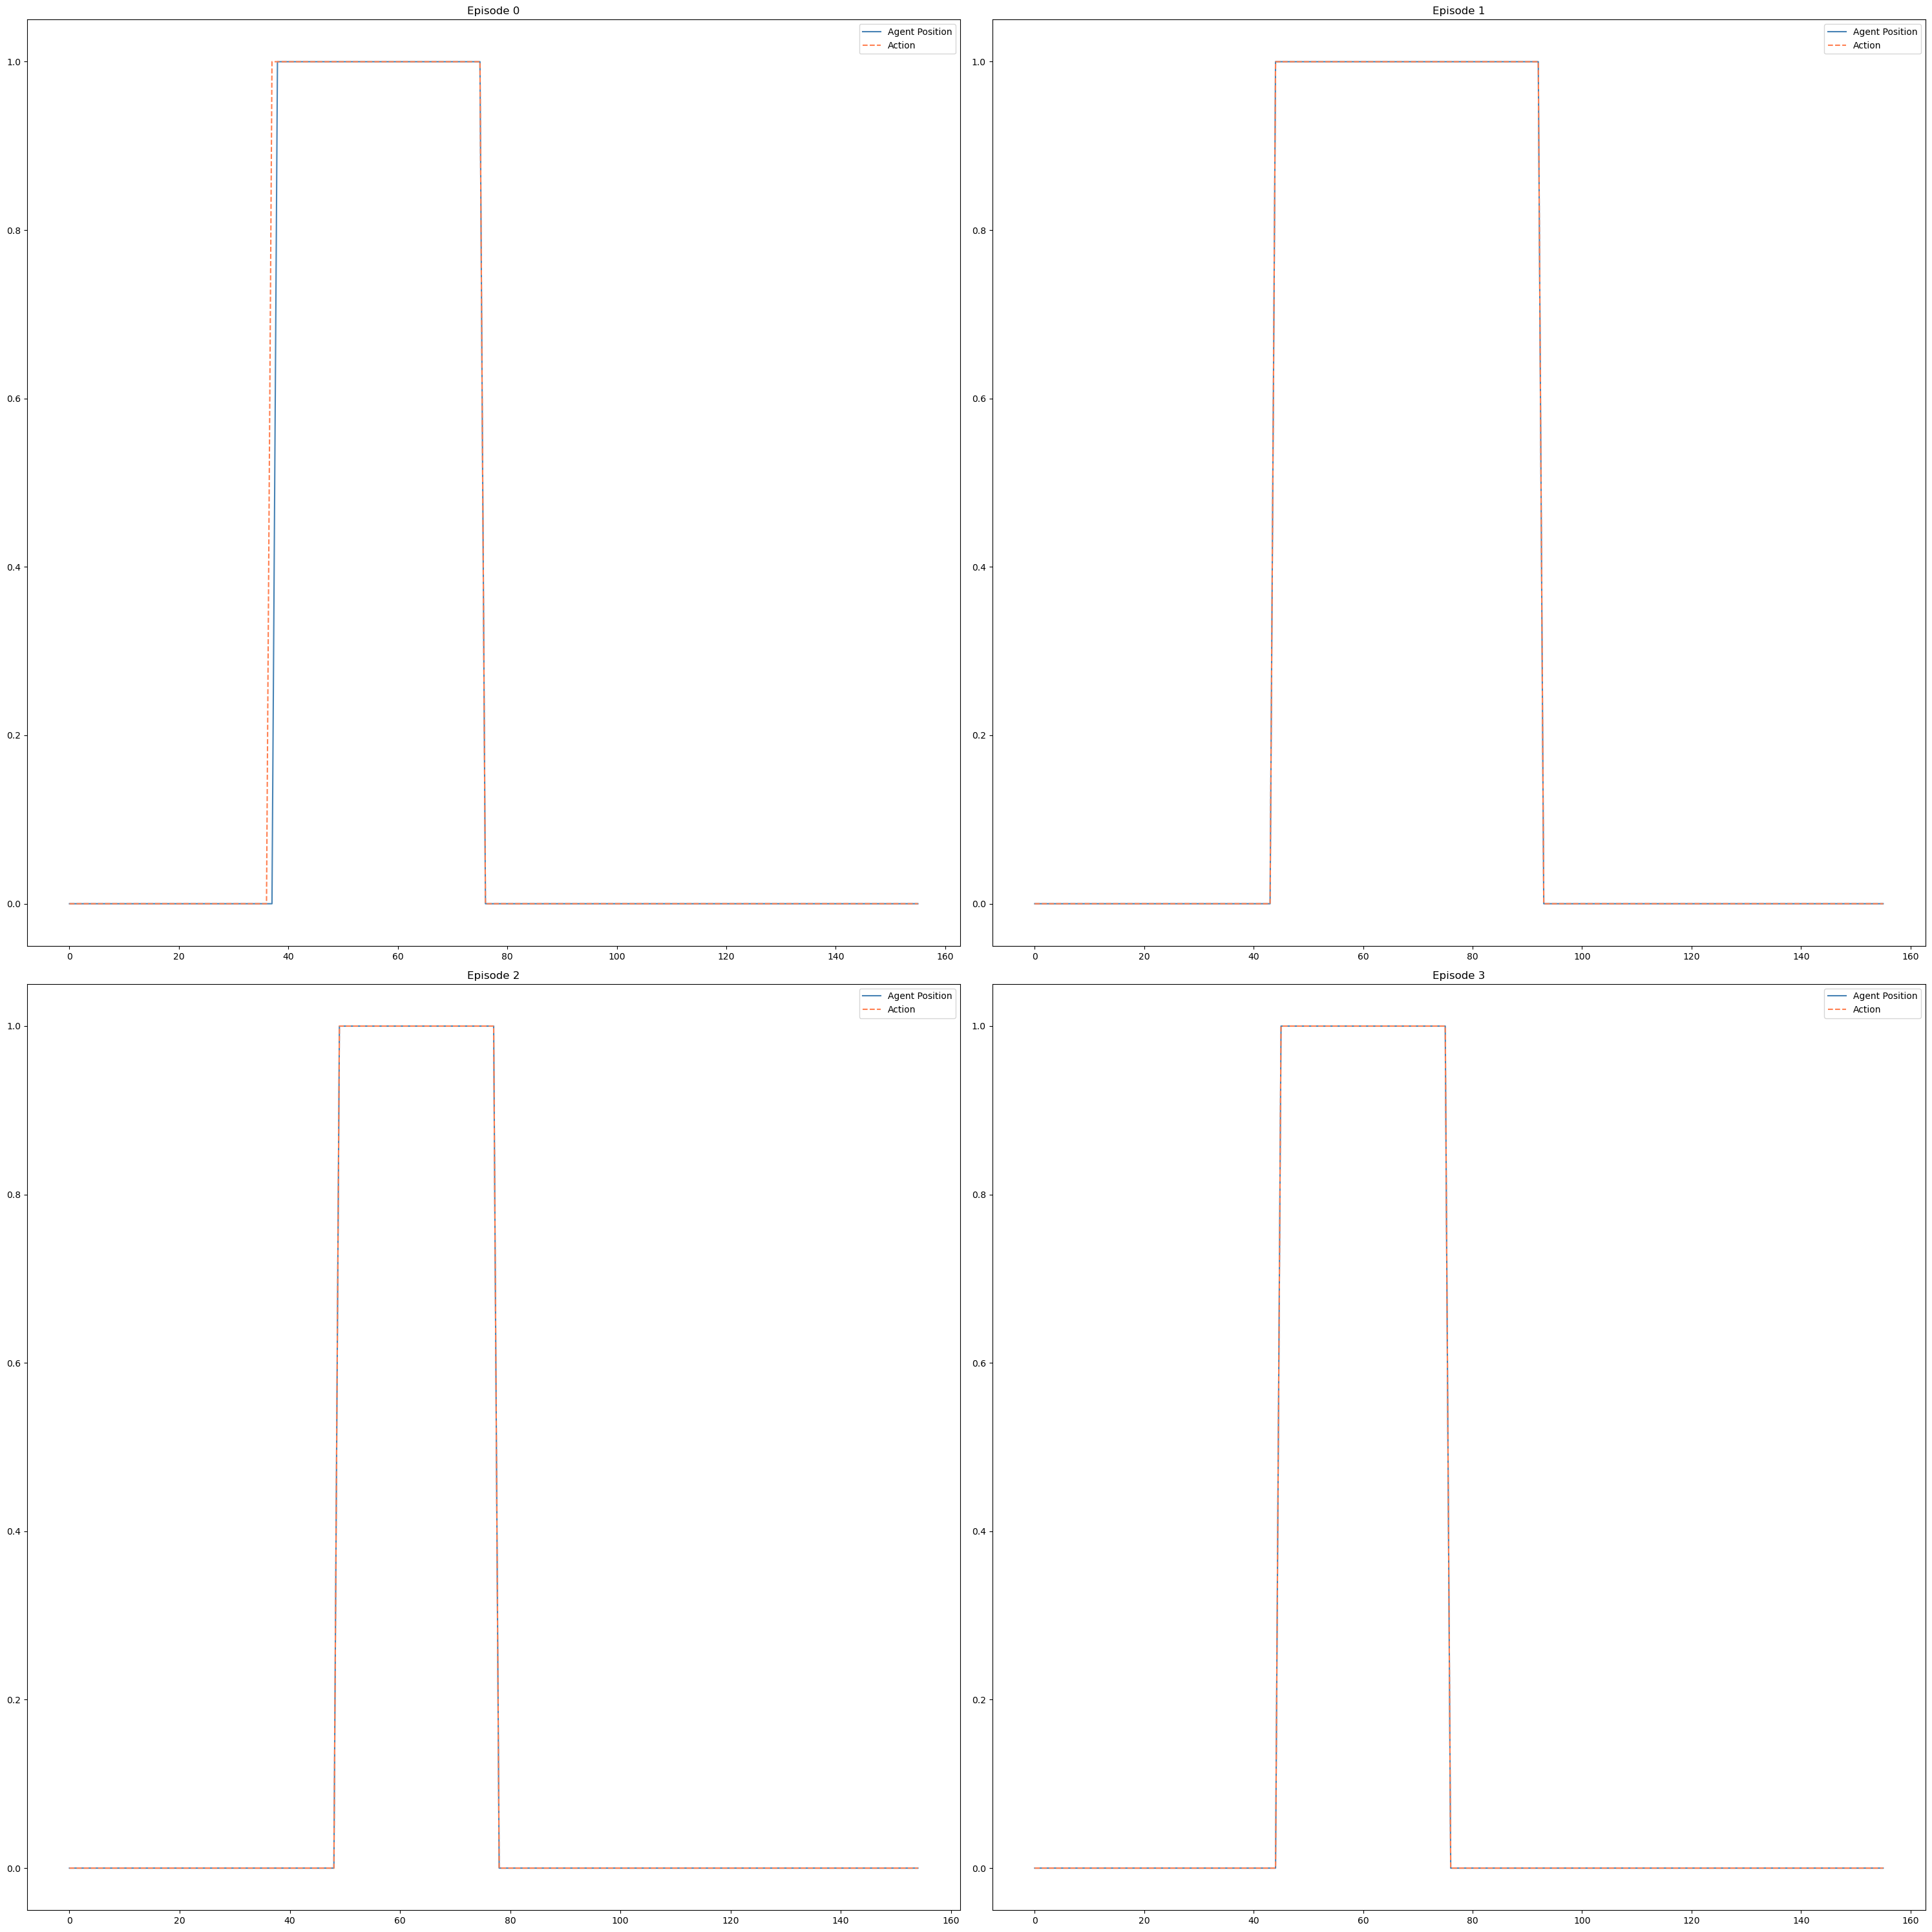

In [15]:
import cv2
import zarr
import numpy as np
import matplotlib.pyplot as plt

# draw dataset
dataset_path = "/app/dataset/kuavo/task_toy/toy_1/zarr/toy_1.zarr"
dataset_root = zarr.open(dataset_path, 'r')

print(dataset_root.tree())
'''/
 ├── data
 │   ├── delta_eef_a (31301, 14) float32
 │   ├── eef_a (31301, 14) float32
 │   ├── eef_s (31301, 14) float32
 │   ├── img01 (31301, 256, 256, 3) uint8
 │   ├── img02 (31301, 256, 256, 3) uint8
 │   ├── joint_a (31301, 16) float32
 │   └── joint_s (31301, 16) float32
 └── meta
     └── episode_ends (201,) int64
'''
train_img01_data = dataset_root['data']['img01'][:]
train_img02_data = dataset_root['data']['img02'][:]


train_data = {
    'agent_pos': dataset_root['data']['joint_s'][:,].copy(),  # 复制避免直接修改原数据
    'action': dataset_root['data']['joint_a'][:].copy(),
}


train_data['agent_pos'][:, [6, 7]] = train_data['agent_pos'][:, [7, 6]]
train_data['action'][:, [6, 7]] = train_data['action'][:, [7, 6]]

agent = dataset_root['data']['eef_s'][:,:8]

episode_ends = dataset_root['meta']['episode_ends'][:]
for key, value in train_data.items():
    print(f"{key}: {value.shape}")
print(episode_ends)

# Plot first 10 episodes and record the video
fig, axs = plt.subplots(2, 2, figsize=(30, 30))
offset = 188
for i in range(4):
    start_idx = offset
    if offset > 0:
        start_idx = episode_ends[offset+i-1]
    end_idx = episode_ends[offset+i]
    episode_length = end_idx - start_idx
    ax = axs[i//2, i%2]
    ax.set_title(f"Episode {i}")
    ax.plot(train_data['agent_pos'][start_idx:end_idx, 7:8], 
        label='Agent Position', color='steelblue', linestyle='solid')
    ax.plot(train_data['action'][start_idx:end_idx, 7:8], 
        label='Action', color='coral', linestyle='dashed')

    ax.legend()
    
    frames_img01 = train_img01_data[start_idx:end_idx]
    frames_img02 = train_img02_data[start_idx:end_idx]
    
    
    # Write frames to a video file in MP4 format
    video_path = f"episode_{i}.mp4"
    out = cv2.VideoWriter(video_path, cv2.VideoWriter_fourcc(*'mp4v'), 10, (512, 256))  # Adjust size for combined frames

    for frame1, frame2 in zip(frames_img01, frames_img02):
        # Combine images horizontally (side-by-side)
        combined_frame = np.concatenate((frame1, frame2), axis=1)  # Axis 1 for horizontal stacking
        combined_frame = cv2.cvtColor(combined_frame, cv2.COLOR_RGB2BGR)  # Convert to BGR for OpenCV
        out.write(combined_frame)
    out.release()

plt.tight_layout()
plt.show()


/
 ├── data
 │   ├── delta_eef_a (31301, 14) float32
 │   ├── eef_a (31301, 14) float32
 │   ├── eef_s (31301, 14) float32
 │   ├── img01 (31301, 256, 256, 3) uint8
 │   ├── img02 (31301, 256, 256, 3) uint8
 │   ├── joint_a (31301, 16) float32
 │   └── joint_s (31301, 16) float32
 └── meta
     └── episode_ends (201,) int64
agent_pos: (31301, 14)
action: (31301, 14)
[  156   312   467   622   777   933  1089  1245  1401  1557  1713  1869
  2025  2181  2336  2491  2647  2803  2959  3115  3271  3427  3583  3739
  3895  4051  4207  4363  4519  4674  4830  4986  5142  5298  5454  5610
  5766  5921  6077  6233  6389  6545  6701  6857  7013  7168  7324  7479
  7635  7791  7946  8102  8258  8413  8569  8725  8880  9036  9191  9346
  9502  9658  9813  9968 10124 10280 10436 10592 10747 10902 11058 11213
 11369 11524 11680 11836 11992 12148 12304 12460 12616 12772 12928 13084
 13240 13396 13551 13706 13862 14018 14174 14330 14485 14641 14797 14952
 15107 15263 15419 15575 15731 15886 16042 1619

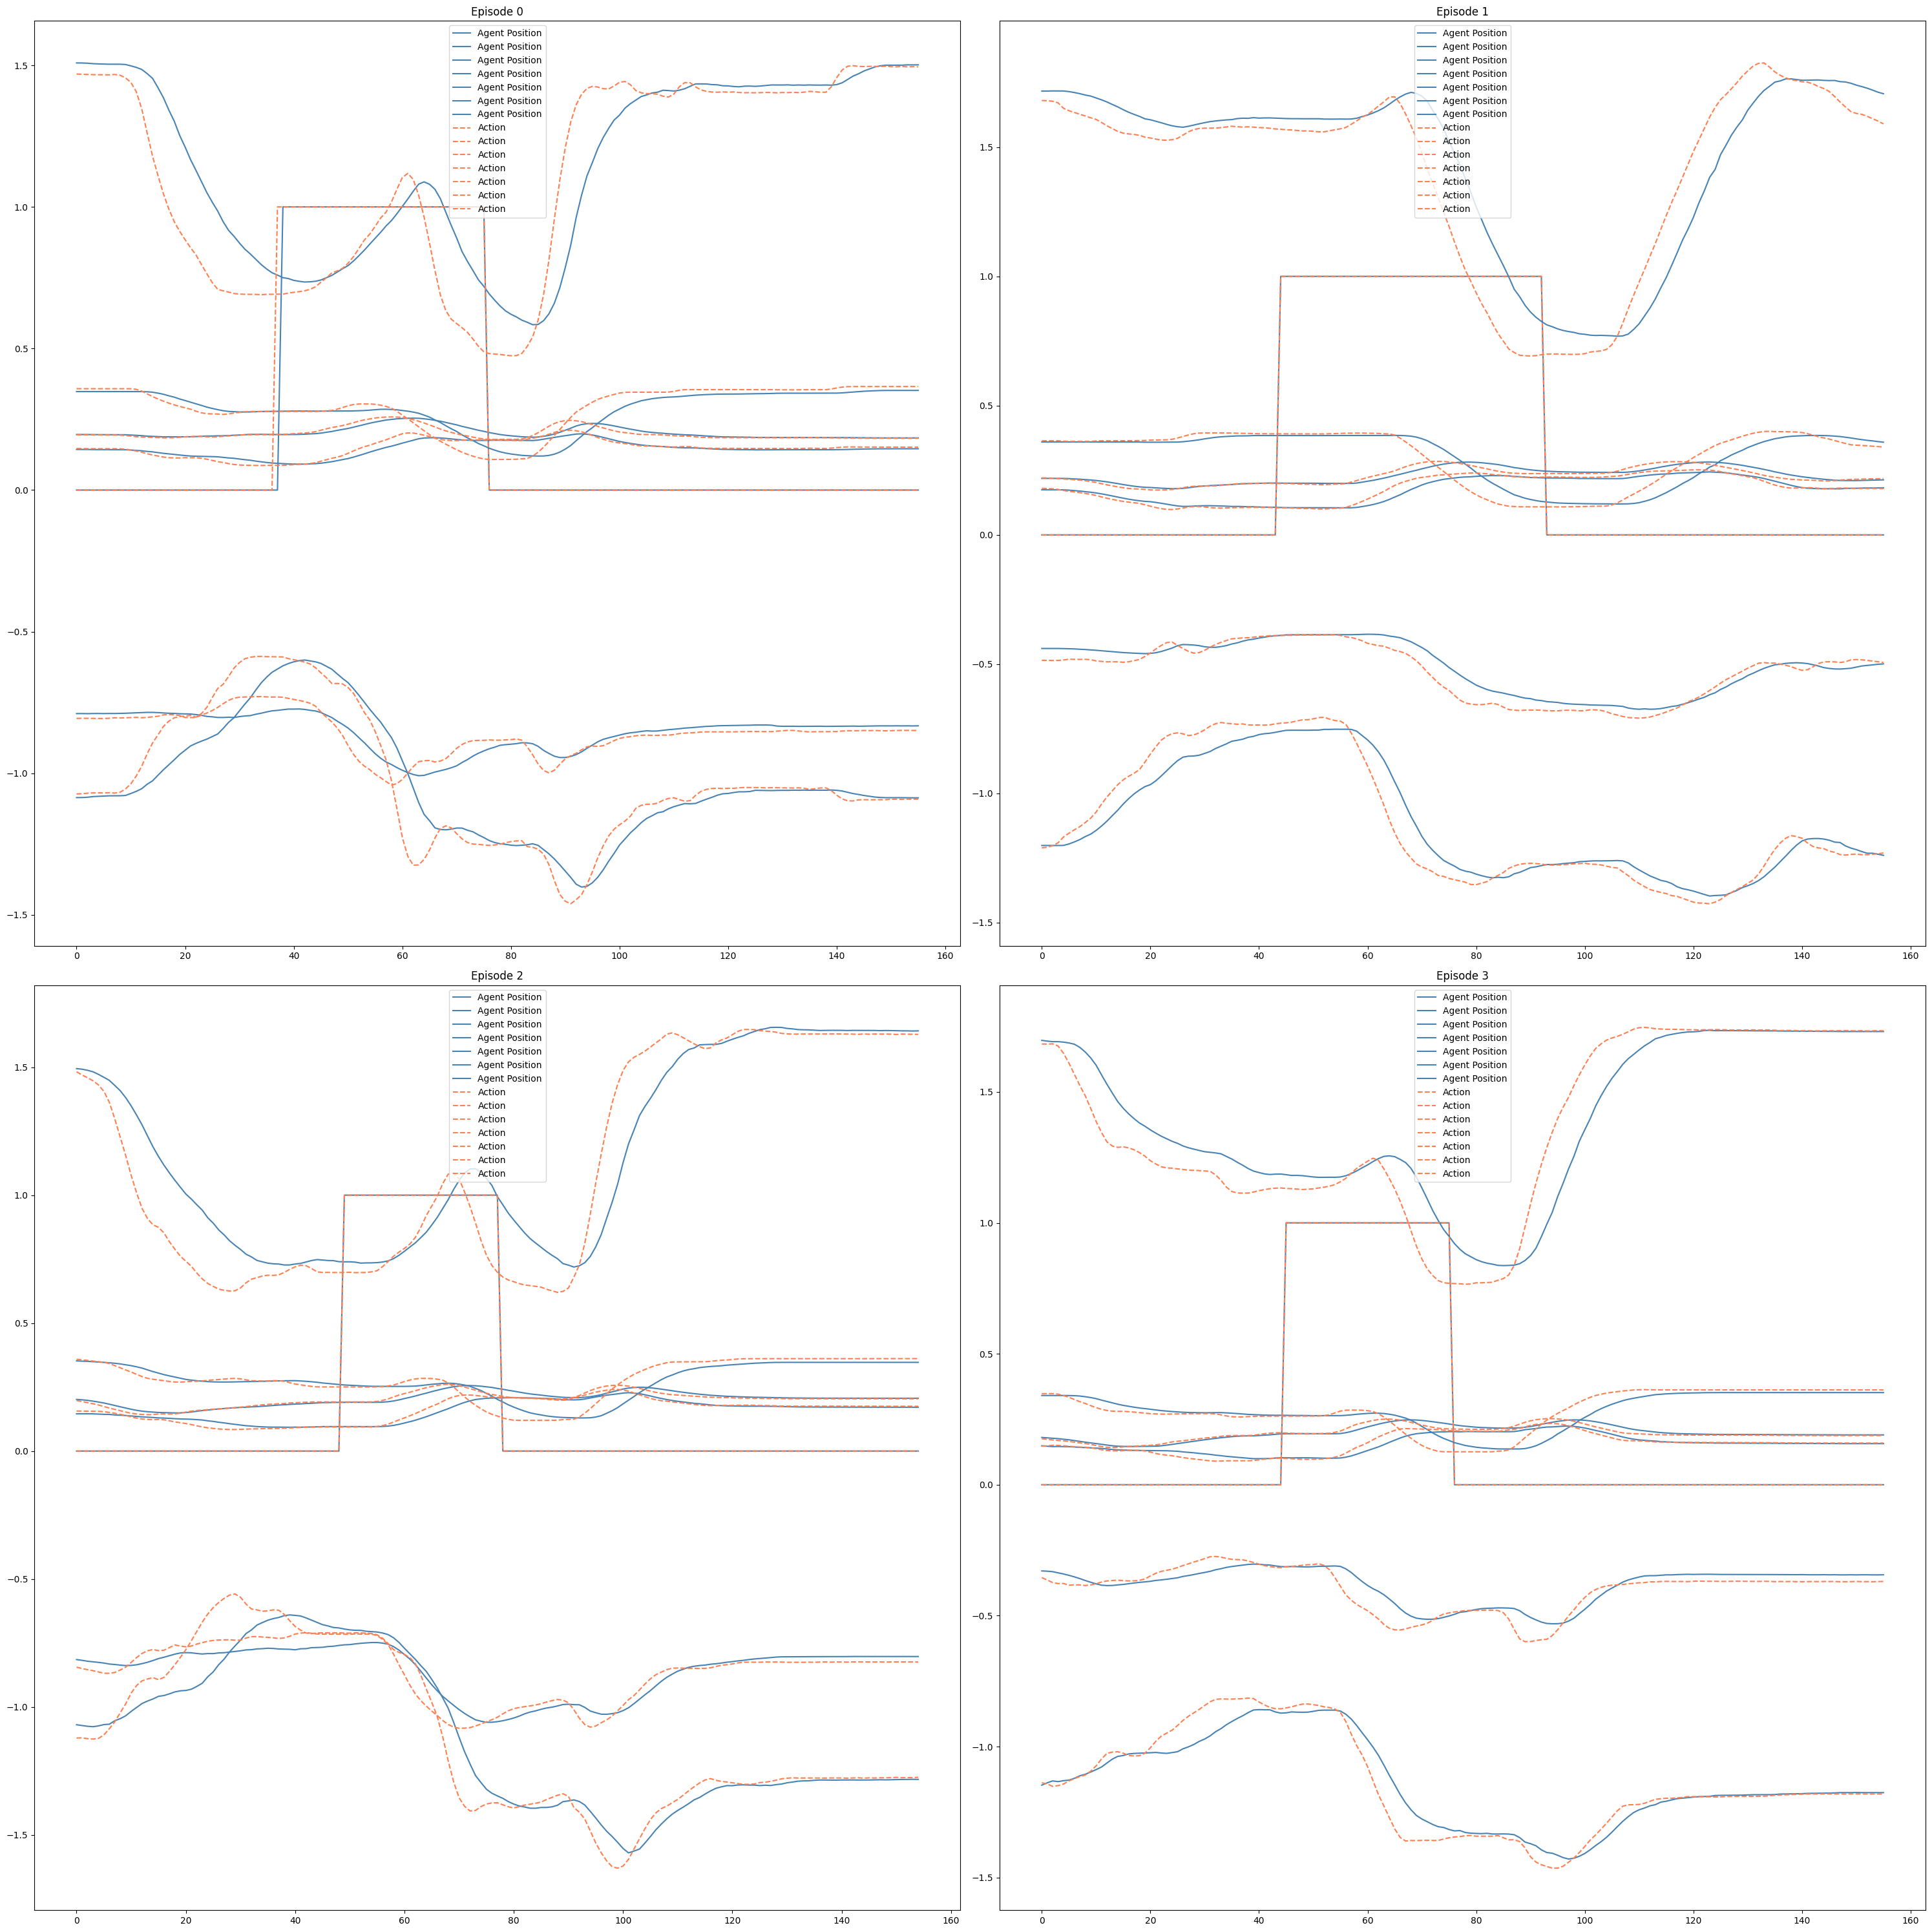

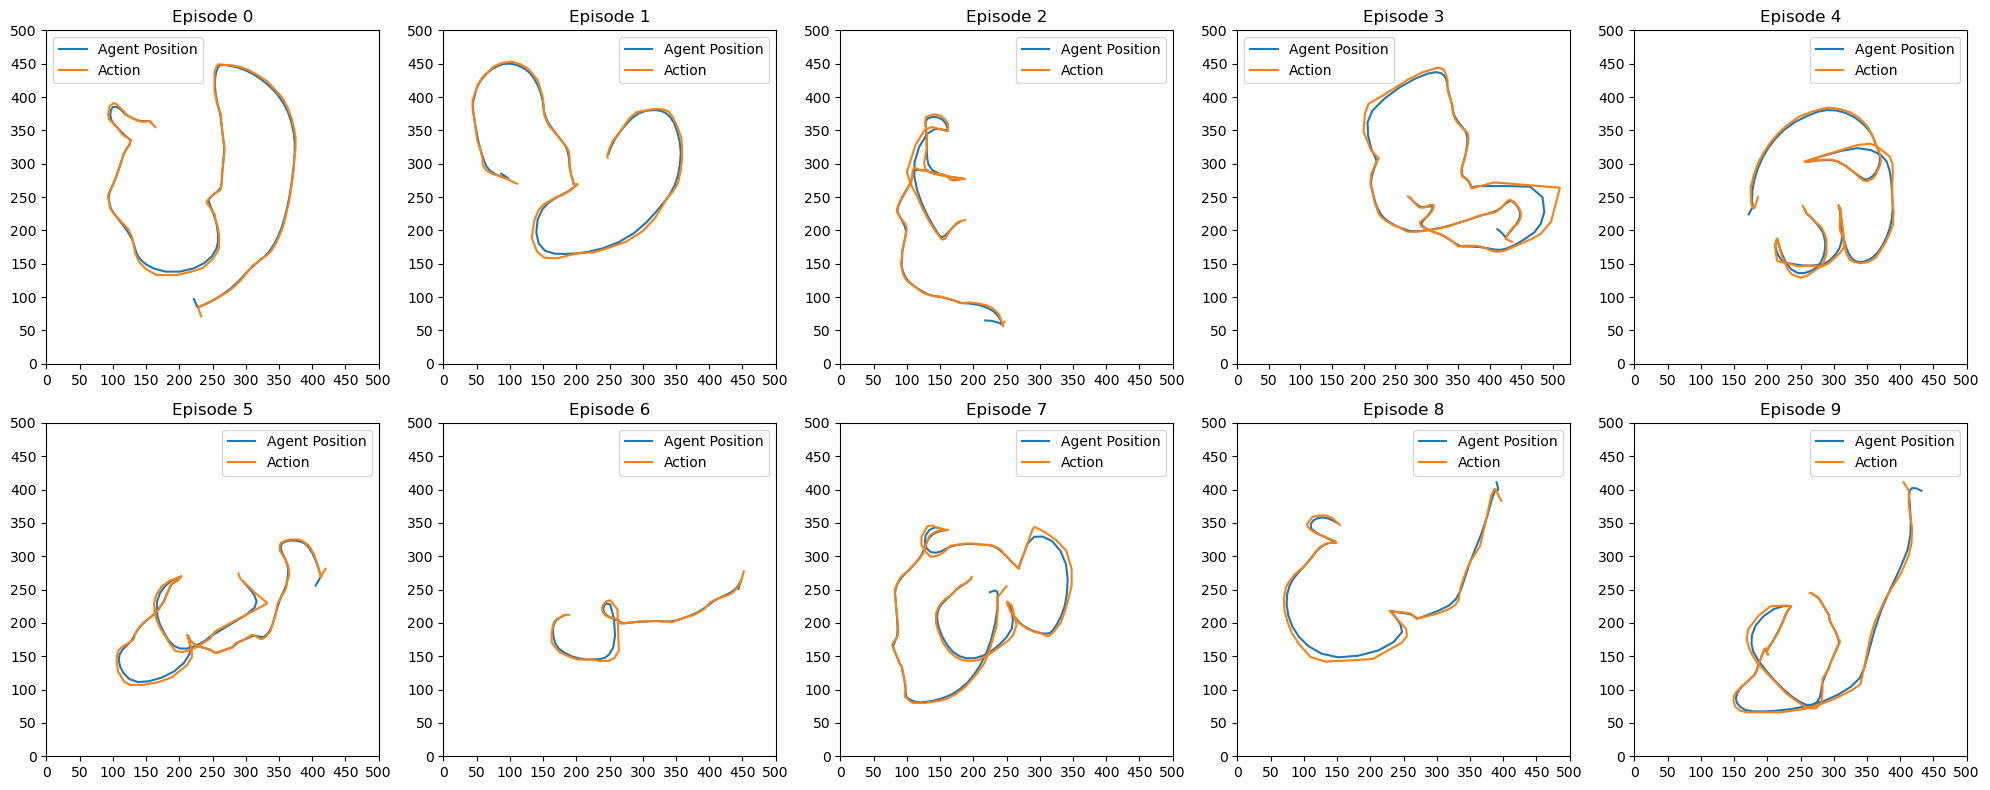

In [ ]:
import cv2
import zarr
import numpy as np
import matplotlib.pyplot as plt

# draw dataset
dataset_path = "pusht_cchi_v7_replay.zarr.zip"
dataset_root = zarr.open(dataset_path, 'r')
train_img01_data = dataset_root['data']['img'][:]
train_img01_data = np.moveaxis(train_img01_data, -1, 1)
train_data = {
    'agent_pos': dataset_root['data']['state'][:,:2],
    'action': dataset_root['data']['action'][:]
}
episode_ends = dataset_root['meta']['episode_ends'][:]
# plot first 10 episodes and record the video
fig, axs = plt.subplots(2, 5, figsize=(20, 8))
for i in range(10):
    start_idx = 0
    if i > 0:
        start_idx = episode_ends[i-1]
    end_idx = episode_ends[i]
    episode_length = end_idx - start_idx
    ax = axs[i//5, i%5]
    ax.set_title(f"Episode {i}")
    ax.plot(train_data['agent_pos'][start_idx:end_idx,0],train_data['agent_pos'][start_idx:end_idx,1], label='Agent Position')
    ax.plot(train_data['action'][start_idx:end_idx,0],train_data['action'][start_idx:end_idx,1], label='Action')
    # 保证每张图之间的x轴刻度一致,y轴刻度一致,y轴一格为50。而且每个图的50长度是一样的
    ax.set_xticks(np.arange(0, 512, 50))
    ax.set_yticks(np.arange(0, 512, 50))
    # ax.set_aspect('equal')
    ax.legend()
    
    # Extract frames from train_img01_data
    frames = train_img01_data[start_idx:end_idx]
    frames = np.moveaxis(frames, 1, -1)
    frames = (frames).astype(np.uint8)
    # Write frames to a video file
    
    video_path = f"episode_{i}.avi"
    out = cv2.VideoWriter(video_path, cv2.VideoWriter_fourcc(*'DIVX'), 10, (96, 96))
    for frame in frames:
        out.write(cv2.cvtColor(frame, cv2.COLOR_RGB2BGR))
    out.release()
    
    

plt.tight_layout()
plt.show()


/
 ├── data
 │   ├── action (1714, 7) float32
 │   ├── img (1714, 96, 96, 3) uint8
 │   └── state (1714, 7) float32
 └── meta
     └── episode_ends (10,) int64
/
 ├── data
 │   ├── action (25650, 2) float32
 │   ├── img (25650, 96, 96, 3) float32
 │   ├── keypoint (25650, 9, 2) float32
 │   ├── n_contacts (25650, 1) float32
 │   └── state (25650, 5) float32
 └── meta
     └── episode_ends (206,) int64
(1714, 7)
(1714, 7)
[ 168  339  510  682  853 1026 1198 1369 1541 1714]


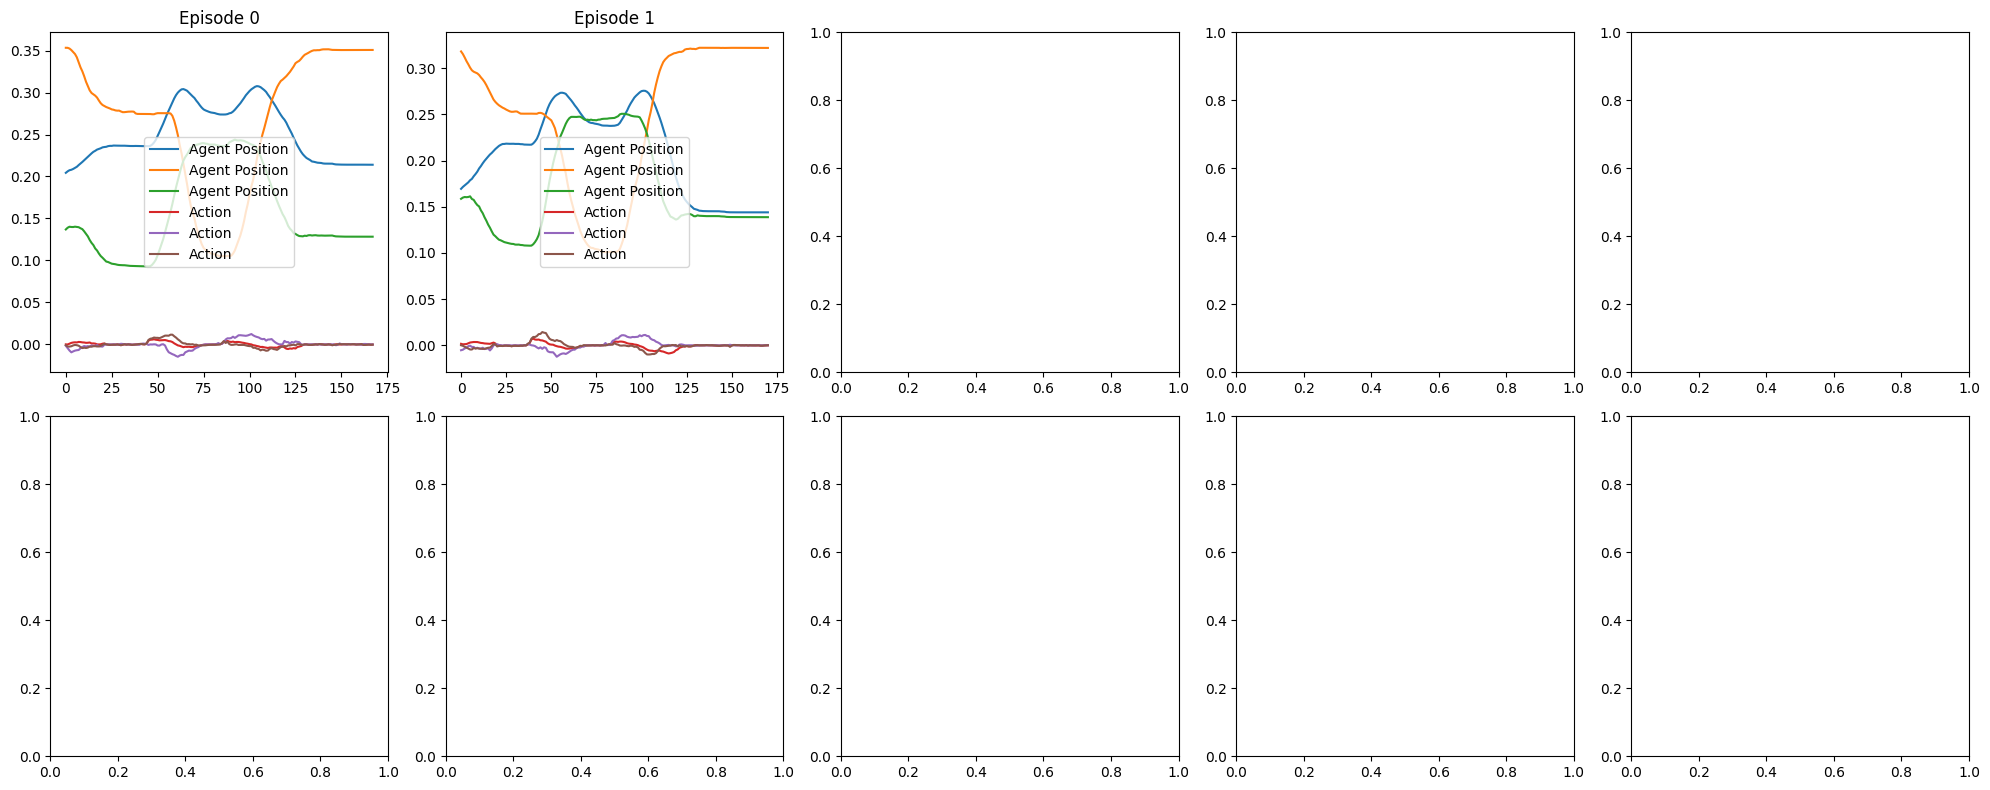

In [ ]:
import cv2
import zarr
import numpy as np
import matplotlib.pyplot as plt

# draw dataset
dataset_path = "/home/lab/hanxiao/dataset/kuavo/task_toy/toy_1/zarr/toy_1.zarr"
dataset_root = zarr.open(dataset_path, 'r')

print(dataset_root.tree())
'''/
 ├── data
 │   ├── delta_eef_a (31301, 14) float32
 │   ├── eef_a (31301, 14) float32
 │   ├── eef_s (31301, 14) float32
 │   ├── img01 (31301, 256, 256, 3) uint8
 │   ├── img02 (31301, 256, 256, 3) uint8
 │   ├── joint_a (31301, 16) float32
 │   └── joint_s (31301, 16) float32
 └── meta
     └── episode_ends (201,) int64
'''
train_img01_data = dataset_root['data']['img01'][:]
train_img02_data = dataset_root['data']['img02'][:]

train_data = {
    'agent_pos': dataset_root['data']['eef_s'][:,],
    'action': dataset_root['data']['eef_a'][:]
}

agent = dataset_root['data']['eef_s'][:,:7]

episode_ends = dataset_root['meta']['episode_ends'][:]
for key, value in train_data.items():
    print(f"{key}: {value.shape}")
print(episode_ends)

# Plot first 10 episodes and record the video
fig, axs = plt.subplots(2, 2, figsize=(30, 30))
offset = 188
for i in range(4):
    start_idx = offset
    if offset > 0:
        start_idx = episode_ends[offset+i-1]
    end_idx = episode_ends[offset+i]
    episode_length = end_idx - start_idx
    ax = axs[i//2, i%2]
    ax.set_title(f"Episode {i}")
    ax.plot(train_data['agent_pos'][start_idx:end_idx, :7], 
        label='Agent Position', color='steelblue', linestyle='solid')
    ax.plot(train_data['action'][start_idx:end_idx, :7], 
        label='Action', color='coral', linestyle='dashed')

    ax.legend()
    
    frames_img01 = train_img01_data[start_idx:end_idx]
    frames_img02 = train_img02_data[start_idx:end_idx]
    
    
    # Write frames to a video file in MP4 format
    video_path = f"episode_{i}.mp4"
    out = cv2.VideoWriter(video_path, cv2.VideoWriter_fourcc(*'mp4v'), 10, (512, 256))  # Adjust size for combined frames

    for frame1, frame2 in zip(frames_img01, frames_img02):
        # Combine images horizontally (side-by-side)
        combined_frame = np.concatenate((frame1, frame2), axis=1)  # Axis 1 for horizontal stacking
        combined_frame = cv2.cvtColor(combined_frame, cv2.COLOR_RGB2BGR)  # Convert to BGR for OpenCV
        out.write(combined_frame)
    out.release()

plt.tight_layout()
plt.show()
